# Importing libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import nltk
from nltk import word_tokenize, pos_tag, WordNetLemmatizer
from nltk.corpus import stopwords, wordnet
import string
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [2]:
data = pd.read_csv("/kaggle/input/datasets/abdelmalekeladjelet/sentiment-analysis-dataset/sentiment_data.csv")
data["text"] = data["Comment"].apply(str)
data["label"] = data["Sentiment"]

data = data.drop(columns=["Unnamed: 0","Comment","Sentiment"])
data.head()

,text,label
0,lets forget apple pay required brand new iphon...,1
1,nz retailers don’t even contactless credit car...,0
2,forever acknowledge channel help lessons ideas...,2
3,whenever go place doesn’t take apple pay doesn...,0
4,apple pay convenient secure easy use used kore...,2


Printing Random data row:  Label | 'Text' 
2 | 'â politics sir work take credit imp thing power reports says pending since modi govt gives approval today feel proud know donâ like modi fact fact nehru long debate' 
random data lengths(chars) = 168
random data lengths(words) = 29
------------------------------------------------
average word length per text: 12.993891641958157
min word length per text: 1
max word length per text: 742
Data count: 241145


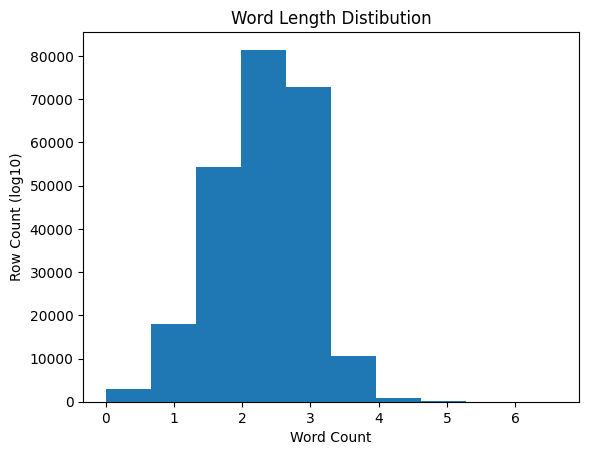

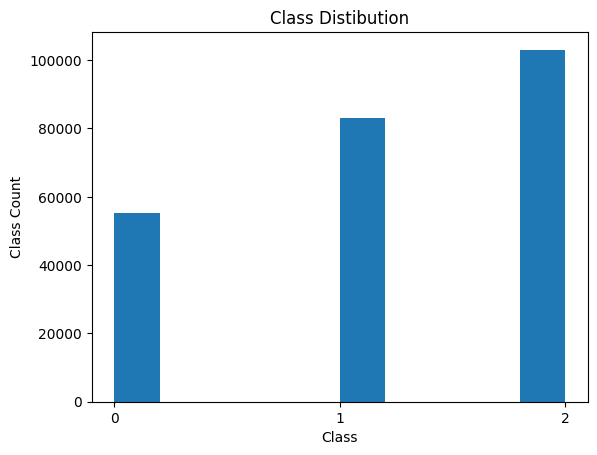

In [3]:
# Exploring/Understanding data properties (before preprocessing)

##defining common variables
sep = "------------------------------------------------"
data["text_word_length"] = data.text.apply( lambda x: len(x.split()) )

## printing randiom data 
#np.random.index(-1)  # set for reproducability
random_index = np.random.randint(len(data))
print("Printing Random data row:  Label | 'Text' ")
print(f"{data.label[random_index]} | '{data.text[random_index]}' ")
print(f"random data lengths(chars) = {len(data.text[random_index])}")
print(f"random data lengths(words) = {len((data.text[random_index]).split())}")


print(sep)
print(f"average word length per text: {data.text_word_length.sum()/len(data)}")
print(f"min word length per text: {data.text_word_length.min()}")
print(f"max word length per text: {data.text_word_length.max()}")
print(f"Data count: {len(data)}")


plt.hist(np.log(data["text_word_length"]))
plt.title("Word Length Distibution")
plt.ylabel("Row Count (log10)")
plt.xlabel("Word Count")
plt.show()

plt.hist(data["label"])
plt.title("Class Distibution")
plt.ylabel("Class Count")
plt.xlabel("Class")
plt.xticks([0,1,2])
plt.show()

In [4]:
def preprocess_text(text):
    tokens =  word_tokenize(text)
    tokens = remove_stopwords(tokens,lang="english")
    tokens = remove_punctuation(tokens)
    tokens = lemmantize_tokens(tokens) 
    #tokens = stem_tokens(tokens)
    return tokens
        

def remove_stopwords(tokens, lang="english"):
    stopWords = stopwords.words(lang)
    return remove_from_list(tokens,stopWords)


def remove_punctuation(tokens):
    return [
        token for token in tokens
        if token not in string.punctuation 
        and token not in ["’"]
    ]
def remove_from_list(lst,to_remove):
     return [x for x in lst if x not in to_remove]

def lemmantize_tokens(tokens):
    tags = pos_tag(tokens)
    lemmatizer = WordNetLemmatizer()

    lem_tokens = []
    for word,tag in tags:
        lem_token = lemmatizer.lemmatize(word.lower(),get_pos(tag))
        lem_tokens.append(lem_token)
    return lem_tokens

def stem_tokens(tokens):
    stemmer = ISRIStemmer()
    return [stemmer.stem(word) for word in tokens]
    
def get_pos(tag):
    if tag.startswith("N"):
        return wordnet.NOUN
    elif tag.startswith("V"):
        return wordnet.VERB
    elif tag.startswith("J"):
        return wordnet.ADJ
    elif tag.startswith("R"):
        return wordnet.ADV
    else: 
        return wordnet.NOUN
    
def preprocess_data(data):
    data.text = data.text.apply(preprocess_text)

preprocess_data(data)
print(data.head())

                                                text  label  text_word_length
0  [let, forget, apple, pay, require, brand, new,...      1                33
1  [nz, retailer, even, contactless, credit, card...      0                18
2  [forever, acknowledge, channel, help, lesson, ...      2                15
3  [whenever, go, place, take, apple, pay, happen...      0                49
4  [apple, pay, convenient, secure, easy, use, us...      2                14


In [5]:
data["clean_text"] = data["text"].apply(lambda lst: " ".join(lst))
print(data["clean_text"].head())

0    let forget apple pay require brand new iphone ...
1    nz retailer even contactless credit card machi...
2    forever acknowledge channel help lesson ideas ...
3    whenever go place take apple pay happen often ...
4    apple pay convenient secure easy use used kore...
Name: clean_text, dtype: object


In [6]:
data.head()

,text,label,text_word_length,clean_text
0,"[let, forget, apple, pay, require, brand, new,...",1,33,let forget apple pay require brand new iphone ...
1,"[nz, retailer, even, contactless, credit, card...",0,18,nz retailer even contactless credit card machi...
2,"[forever, acknowledge, channel, help, lesson, ...",2,15,forever acknowledge channel help lesson ideas ...
3,"[whenever, go, place, take, apple, pay, happen...",0,49,whenever go place take apple pay happen often ...
4,"[apple, pay, convenient, secure, easy, use, us...",2,14,apple pay convenient secure easy use used kore...


In [7]:
from collections import Counter
from itertools import chain

all_tokens = list(chain.from_iterable(data.text))
word_counts = Counter(all_tokens)
print(word_counts.most_common(10))
print(word_counts.most_common()[-10:])

[('modi', 149679), ('india', 28330), ('get', 20300), ('like', 19821), ('say', 18863), ('people', 16251), ('make', 16221), ('one', 14635), ('give', 14485), ('bjp', 14149)]
[('antifake', 1), ('graft', 1), ('rumorswhy', 1), ('partyalliance', 1), ('â\x80\x9ccommunismâ\x80\x9d', 1), ('â\x80\x9chindutvaâ\x80\x9d', 1), ('azamgarh', 1), ('jogiadhiyanath', 1), ('goudi', 1), ('â\x80\x9cstoicâ\x80\x9d', 1)]


In [8]:
print(word_counts.most_common(200))
print(word_counts.most_common()[-200:])
print(len(word_counts))

[('modi', 149679), ('india', 28330), ('get', 20300), ('like', 19821), ('say', 18863), ('people', 16251), ('make', 16221), ('one', 14635), ('give', 14485), ('bjp', 14149), ('time', 14119), ('go', 13176), ('congress', 12499), ('good', 12100), ('dont', 12094), ('vote', 11987), ('know', 11713), ('work', 11553), ('take', 11521), ('election', 11459), ('want', 11361), ('narendra', 11344), ('year', 11240), ('see', 10748), ('day', 10478), ('come', 10137), ('govt', 9731), ('think', 9424), ('indian', 8913), ('even', 8885), ('well', 8697), ('need', 8540), ('country', 8529), ('would', 8420), ('also', 8313), ('love', 8129), ('great', 7746), ('modis', 7740), ('im', 7623), ('use', 7618), ('nation', 7183), ('back', 7077), ('rahul', 6997), ('app', 6705), ('much', 6614), ('party', 6560), ('new', 6318), ('today', 6217), ('thing', 6207), ('government', 6142), ('support', 6113), ('really', 6091), ('power', 5927), ('show', 5872), ('do', 5814), ('look', 5751), ('minister', 5721), ('cant', 5690), ('gandhi', 56

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

cv = TfidfVectorizer(max_features=10000,min_df=5,max_df=0.95)
x = data.clean_text
y = data.label

x = cv.fit_transform(x).toarray()

print(f"x.shape: {x.shape}")
print(f"y.shape: {y.shape}")
print(f"sample x:\n {x[:5]}")
print(f"sample y:\n {y.head()}")

x.shape: (241145, 10000)
y.shape: (241145,)
sample x:
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
sample y:
 0    1
1    0
2    2
3    0
4    2
Name: label, dtype: int64


In [10]:
import pickle

vectorizer_model_path = "/kaggle/working/english_vectorizer_model.pkl"

print("Saving TfidfVectorizer model...")
with open(vectorizer_model_path, 'wb') as file:
    # Use pickle.dump to serialize the model object and write it to the file
    pickle.dump(cv, file)
print(f"Done saving model to {vectorizer_model_path}")

Saving TfidfVectorizer model...
Done saving model to /kaggle/working/english_vectorizer_model.pkl


In [11]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.8)

In [12]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(x_train, y_train)

MultinomialNB()

In [13]:
from sklearn.metrics import classification_report

y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.42      0.55     11059
           1       0.65      0.57      0.61     16538
           2       0.62      0.84      0.71     20632

    accuracy                           0.65     48229
   macro avg       0.68      0.61      0.62     48229
weighted avg       0.67      0.65      0.64     48229



In [14]:
import pickle

model_path = "/kaggle/working/english_classifier_model.pkl"

print("Saving model...")
with open(model_path, 'wb') as file:
    # Use pickle.dump to serialize the model object and write it to the file
    pickle.dump(model, file)
print(f"Done saving model to {model_path}")

Saving model...
Done saving model to /kaggle/working/english_classifier_model.pkl


In [15]:
with open(model_path,"rb") as file:
    loaded_model = pickle.load(file)
with open(vectorizer_model_path,"rb") as file:
    loaded_vectorizer = pickle.load(file)
    
text = "Sad Sad Bad, Mad Lad, Criminal"
text_df = pd.DataFrame([text],columns=['text'])
print(text_df,'\n')
preprocess_data(text_df)
print(text_df,'\n')
text = ' '.join(text_df.text[0])
text_df = pd.DataFrame([text],columns=['text'])

#turn to numeric
text_cv = loaded_vectorizer.transform(text_df)
print(text_cv)
loaded_model.predict(text_cv)

                             text
0  Sad Sad Bad, Mad Lad, Criminal 

                                  text
0  [sad, sad, bad, mad, lad, criminal] 

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1 stored elements and shape (1, 10000)>
  Coords	Values
  (0, 8885)	1.0


array([1])